# Notebook 01: Model Exploration and Activation Extraction

This notebook:
1. Loads a biomedical language model (BioGPT)
2. Extracts activations for a dataset of drug-target interaction prompts
3. Visualizes activation statistics across layers
4. Prepares data for downstream probing analysis

**Key outputs:** ActivationDataset saved to disk, activation statistics plots, layer-wise dimensionality analysis.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
import json

sys.path.insert(0, str(Path.cwd().parent / 'src'))

from models import BioModel, ModelConfig
from activations import ActivationExtractor, ActivationDataset
import visualization as viz

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Configuration

In [2]:
config_path = Path.cwd().parent / 'configs' / 'model_config.yaml'
with open(config_path) as f:
    config_dict = yaml.safe_load(f)

print('=' * 70)
print('BIOLENS: MODEL EXPLORATION AND ACTIVATION EXTRACTION')
print('=' * 70)
print(f"\nModel: {config_dict['model']['name']}")
print(f"Device: {config_dict['model']['device']}")
print(f"Pooling: {config_dict['extraction']['pooling']}")

BIOLENS: MODEL EXPLORATION AND ACTIVATION EXTRACTION

Model: microsoft/biogpt
Device: cpu
Pooling: mean


## 2. Load Model

In [3]:
print('\n[1/4] Loading model...')
model_config = ModelConfig(
    model_name=config_dict['model']['name'],
    device=config_dict['model']['device'],
    use_transformer_lens=config_dict['model']['use_transformer_lens'],
)
model = BioModel(model_config)
print(f'✓ Loaded: {model}')


[1/4] Loading model...
Loading microsoft/biogpt via HuggingFace...


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

Loaded: 24 layers, d_model=1024
✓ Loaded: BioModel(name=microsoft/biogpt, mode=huggingface, layers=24, d_model=1024)


## 3. Extract Activations

In [4]:
print('\n[2/4] Extracting activations from prompts...')
extractor = ActivationExtractor(
    model=model,
    pooling=config_dict['extraction']['pooling'],
    batch_size=config_dict['extraction']['batch_size'],
    cache_dir=config_dict['extraction']['cache_dir'],
)
prompts_path = Path.cwd().parent / config_dict['prompts']['drug_target_pairs']
dataset = extractor.extract_from_jsonl(
    jsonl_path=str(prompts_path),
    text_field='text',
    label_fields=['mechanism', 'target_family', 'toxicity_class', 'pathway'],
)
print(f'✓ Extracted: {dataset.n_prompts} prompts, {len(dataset.layers)} layers')
print(f'  Activation shape per layer: ({dataset.n_prompts}, {dataset.d_model})')
print(f'  Concepts: {list(dataset.labels.keys())}')


[2/4] Extracting activations from prompts...
Extracting activations for 10 prompts...


  0%|                                                    | 0/10 [00:00<?, ?it/s]

 10%|████▍                                       | 1/10 [00:00<00:04,  2.08it/s]

 30%|█████████████▏                              | 3/10 [00:00<00:01,  5.60it/s]

model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

 50%|██████████████████████                      | 5/10 [00:00<00:00,  8.53it/s]

 70%|██████████████████████████████▊             | 7/10 [00:00<00:00, 10.47it/s]

 90%|███████████████████████████████████████▌    | 9/10 [00:01<00:00, 11.95it/s]

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  9.37it/s]

Saved ActivationDataset (10 prompts, 24 layers) to data/cached_activations/178fd2d155d6
✓ Extracted: 10 prompts, 24 layers
  Activation shape per layer: (10, 1024)
  Concepts: ['mechanism', 'target_family', 'toxicity_class', 'pathway']


## 4. Analyze Activation Statistics

In [5]:
print('\n[3/4] Computing activation statistics...')
layer_stats = {}
for layer_name in dataset.layers:
    acts = dataset.activations[layer_name]
    layer_stats[layer_name] = {
        'mean': float(np.mean(acts)),
        'std': float(np.std(acts)),
        'min': float(np.min(acts)),
        'max': float(np.max(acts)),
        'norm': float(np.linalg.norm(acts) / np.sqrt(acts.size)),
    }
print('\nLayer-wise activation norms (avg L2 norm per sample):')
for layer in dataset.layers[:5]:
    print(f'  {layer}: {layer_stats[layer]["norm"]:.4f}')
print('  ...')
for layer in dataset.layers[-2:]:
    print(f'  {layer}: {layer_stats[layer]["norm"]:.4f}')
print('\nConcept label distributions:')
for concept, labels in dataset.labels.items():
    unique, counts = np.unique(labels, return_counts=True)
    print(f'\n  {concept}:')
    for label_id, count in zip(unique, counts):
        print(f'    Label {label_id}: {count} samples')


[3/4] Computing activation statistics...

Layer-wise activation norms (avg L2 norm per sample):
  layer_0: 1.5438
  layer_1: 1.6806
  layer_2: 1.7649
  layer_3: 1.8545
  layer_4: 1.9573
  ...
  layer_22: 3.3655
  layer_23: 3.2864

Concept label distributions:

  mechanism:
    Label 0: 1 samples
    Label 1: 2 samples
    Label 2: 1 samples
    Label 3: 1 samples
    Label 4: 3 samples
    Label 5: 2 samples

  target_family:
    Label 0: 1 samples
    Label 1: 2 samples
    Label 2: 1 samples
    Label 3: 1 samples
    Label 4: 1 samples
    Label 5: 1 samples
    Label 6: 1 samples
    Label 7: 2 samples

  toxicity_class:
    Label 0: 1 samples
    Label 1: 2 samples
    Label 2: 1 samples
    Label 3: 1 samples
    Label 4: 3 samples
    Label 5: 1 samples
    Label 6: 1 samples

  pathway:
    Label 0: 10 samples


## 5. Save Dataset

In [6]:
print('\n[4/4] Saving dataset...')
output_dir = Path.cwd().parent / 'data' / 'processed' / 'activation_dataset_v1'
output_dir.mkdir(parents=True, exist_ok=True)
dataset.save(str(output_dir))
print(f'✓ Saved to {output_dir}')
with open(output_dir / 'layer_statistics.json', 'w') as f:
    json.dump(layer_stats, f, indent=2)
print('✓ Saved layer statistics')


[4/4] Saving dataset...
Saved ActivationDataset (10 prompts, 24 layers) to /Users/spoddar/Downloads/Career/Pivot/bio-interp/data/processed/activation_dataset_v1
✓ Saved to /Users/spoddar/Downloads/Career/Pivot/bio-interp/data/processed/activation_dataset_v1
✓ Saved layer statistics


## 6. Visualizations

Generating visualizations...


✓ Saved figure: 01_activation_exploration.png


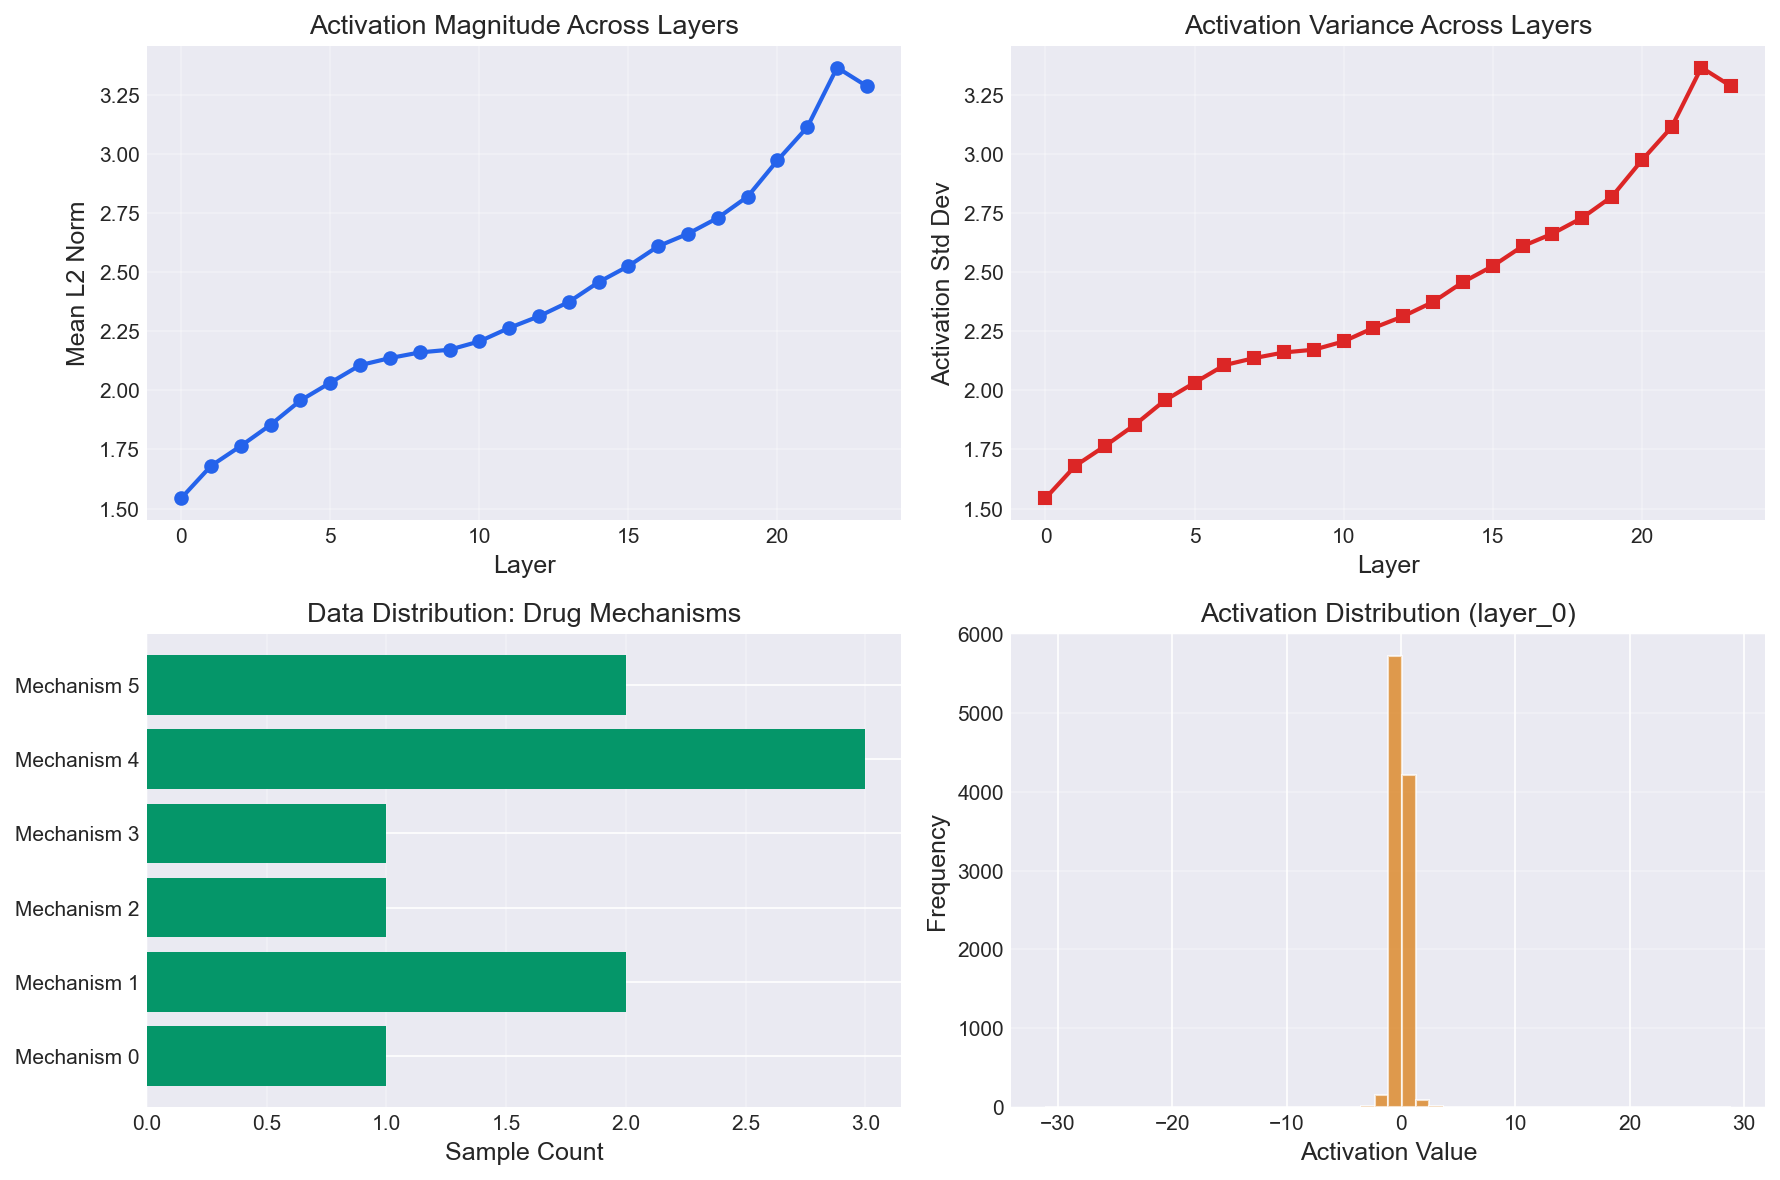


✓ Notebook 01 complete!

Next: Run notebook 02_probing_classifiers.ipynb


In [7]:
print('Generating visualizations...')
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

layer_norms = [layer_stats[layer]['norm'] for layer in dataset.layers]
layer_nums = [int(layer.split('_')[1]) for layer in dataset.layers]
axes[0,0].plot(layer_nums, layer_norms, 'o-', color='#2563EB', linewidth=2)
axes[0,0].set_xlabel('Layer'); axes[0,0].set_ylabel('Mean L2 Norm')
axes[0,0].set_title('Activation Magnitude Across Layers'); axes[0,0].grid(True, alpha=0.3)

layer_vars = [layer_stats[layer]['std'] for layer in dataset.layers]
axes[0,1].plot(layer_nums, layer_vars, 's-', color='#DC2626', linewidth=2)
axes[0,1].set_xlabel('Layer'); axes[0,1].set_ylabel('Activation Std Dev')
axes[0,1].set_title('Activation Variance Across Layers'); axes[0,1].grid(True, alpha=0.3)

mechanisms = dataset.labels['mechanism']
unique_mech, counts = np.unique(mechanisms, return_counts=True)
axes[1,0].barh(range(len(unique_mech)), counts, color='#059669')
axes[1,0].set_yticks(range(len(unique_mech)))
axes[1,0].set_yticklabels([f'Mechanism {m}' for m in unique_mech])
axes[1,0].set_xlabel('Sample Count'); axes[1,0].set_title('Data Distribution: Drug Mechanisms')
axes[1,0].grid(True, alpha=0.3, axis='x')

first_layer_acts = dataset.activations[dataset.layers[0]].flatten()
axes[1,1].hist(first_layer_acts, bins=50, color='#D97706', alpha=0.7, edgecolor='white')
axes[1,1].set_xlabel('Activation Value'); axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title(f'Activation Distribution ({dataset.layers[0]})')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
figures_dir = Path.cwd().parent / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / '01_activation_exploration.png', dpi=300, bbox_inches='tight')
print('✓ Saved figure: 01_activation_exploration.png')
plt.show()
print('\n' + '=' * 70)
print('✓ Notebook 01 complete!')
print('=' * 70)
print('\nNext: Run notebook 02_probing_classifiers.ipynb')